In [1]:
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path
from cartopy import crs as ccrs # Cartography library
import geopy.distance
import re
import pandas as pd
import cartopy.feature as cfeature
import matplotlib.patches as patches
import cmweather as cmw

In [2]:
### Link of the data
root = "ipfs://QmTSoNnvXX9bzu5SgVHeP7hVCuqJKFAkjk21LvzzCSGz9p"

In [3]:
### Calling radiosondes from METEOR
ds_mrr_rainflag= xr.open_dataset(
    f"{root}/mrr_rainflag.zarr",engine="zarr")

ds_cloudnet = xr.open_dataset(
    f"{root}/cloudnet.zarr",engine="zarr")

ds_rain_gauge = xr.open_dataset(
    f"{root}/rain_gauge/M203_Niederschlag_Stand_240923-2227.zarr",engine="zarr")

ds_disdrometer = xr.open_dataset(
    f"{root}/disdrometer/DSD_METEOR_merged.zarr",engine="zarr")

In [4]:
ds_disdrometer_1 = xr.open_dataset(
    f"{root}/disdrometer/DSD_METEOR1_RES.zarr",engine="zarr")
ds_disdrometer_2 = xr.open_dataset(
    f"{root}/disdrometer/DSD_METEOR2_RES.zarr",engine="zarr")

In [5]:
### resample 1 minute
mrr_flag_1min = ds_mrr_rainflag.rain_flag.resample(time='1min').max()
cloudnet_flag_1min = ds_cloudnet.rain_detected.resample(time='1min').max()

rain_gauge_1min = ds_rain_gauge.RR_SRM.resample(time='1min').mean()
rain_gauge_flag_1min = rain_gauge_1min.where(rain_gauge_1min == 0, 1)

rain_disdrometer1_1min = ds_disdrometer_1.rain_rate_qc.resample(time='1min').mean()
rain_disdrometer1_flag_1min = rain_disdrometer1_1min.where(rain_disdrometer1_1min == 0, 1)

rain_disdrometer2_1min = ds_disdrometer_2.rain_rate_qc.resample(time='1min').mean()
rain_disdrometer2_flag_1min = rain_disdrometer2_1min.where(rain_disdrometer2_1min == 0, 1)

In [6]:
mrr_flag_5min = ds_mrr_rainflag.rain_flag.resample(time='5min').max()
cloudnet_flag_5min = ds_cloudnet.rain_detected.resample(time='5min').max()
rain_gauge_flag_5min = ds_rain_gauge.RR_SRM.resample(time='5min').mean().where(ds_rain_gauge.RR_SRM.resample(time='5min').mean() == 0, 1)
rain_disdrometer1_flag_5min = ds_disdrometer_1.rain_rate_qc.resample(time='5min').mean().where(ds_disdrometer_1.rain_rate_qc.resample(time='5min').mean() == 0, 1)
rain_disdrometer2_flag_5min = ds_disdrometer_2.rain_rate_qc.resample(time='5min').mean().where(ds_disdrometer_2.rain_rate_qc.resample(time='5min').mean() == 0, 1)

In [7]:
mrr_flag_10min = ds_mrr_rainflag.rain_flag.resample(time='10min').max()
cloudnet_flag_10min = ds_cloudnet.rain_detected.resample(time='10min').max()
rain_gauge_flag_10min = ds_rain_gauge.RR_SRM.resample(time='10min').mean().where(ds_rain_gauge.RR_SRM.resample(time='10min').mean() == 0, 1)
rain_disdrometer1_flag_10min = ds_disdrometer_1.rain_rate_qc.resample(time='10min').mean().where(ds_disdrometer_1.rain_rate_qc.resample(time='10min').mean() == 0, 1)
rain_disdrometer2_flag_10min = ds_disdrometer_2.rain_rate_qc.resample(time='10min').mean().where(ds_disdrometer_2.rain_rate_qc.resample(time='10min').mean() == 0, 1)

In [8]:
rain_flag_1min =mrr_flag_1min+ cloudnet_flag_1min +rain_gauge_flag_1min + rain_disdrometer1_flag_1min + rain_disdrometer2_flag_1min
rain_flag_5min =mrr_flag_5min+ cloudnet_flag_5min +rain_gauge_flag_5min + rain_disdrometer1_flag_5min + rain_disdrometer2_flag_5min
rain_flag_10min =mrr_flag_10min+ cloudnet_flag_10min +rain_gauge_flag_10min + rain_disdrometer1_flag_10min + rain_disdrometer2_flag_10min

In [9]:
##total number of rain events
total_events = [(rain_flag_1min.where((rain_flag_1min >= 1),drop=True)*0+1).sum().values,
    (rain_flag_5min.where((rain_flag_5min >= 1),drop=True)*0+1).sum().values,
    (rain_flag_10min.where((rain_flag_10min >= 1),drop=True)*0+1).sum().values]
## percentage of rain events detected by 4,3,2,1 instruments
percentages_1min = [(rain_flag_1min.where(rain_flag_1min == 5,drop=True)*0+1).sum().values/total_events[0]*100,
 (rain_flag_1min.where(rain_flag_1min == 4,drop=True)*0+1).sum().values/total_events[0]*100,
 (rain_flag_1min.where(rain_flag_1min == 3,drop=True)*0+1).sum().values/total_events[0]*100,
 (rain_flag_1min.where(rain_flag_1min == 2,drop=True)*0+1).sum().values/total_events[0]*100,
 (rain_flag_1min.where(rain_flag_1min == 1,drop=True)*0+1).sum().values/total_events[0]*100]

percentages_5min = [(rain_flag_5min.where(rain_flag_5min == 5,drop=True)*0+1).sum().values/total_events[1]*100,
 (rain_flag_5min.where(rain_flag_5min == 4,drop=True)*0+1).sum().values/total_events[1]*100,
 (rain_flag_5min.where(rain_flag_5min == 3,drop=True)*0+1).sum().values/total_events[1]*100,
 (rain_flag_5min.where(rain_flag_5min == 2,drop=True)*0+1).sum().values/total_events[1]*100,
 (rain_flag_5min.where(rain_flag_5min == 1,drop=True)*0+1).sum().values/total_events[1]*100]

percentages_10min = [(rain_flag_10min.where(rain_flag_10min == 5,drop=True)*0+1).sum().values/total_events[2]*100,
 (rain_flag_10min.where(rain_flag_10min == 4,drop=True)*0+1).sum().values/total_events[2]*100,
 (rain_flag_10min.where(rain_flag_10min == 3,drop=True)*0+1).sum().values/total_events[2]*100,
 (rain_flag_10min.where(rain_flag_10min == 2,drop=True)*0+1).sum().values/total_events[2]*100,
 (rain_flag_10min.where(rain_flag_10min == 1,drop=True)*0+1).sum().values/total_events[2]*100]

In [10]:
##total number of rain events detected in 1 instrument
total_events_1_instrument = [(rain_flag_1min.where(rain_flag_1min == 1,drop=True)*0+1).sum().values,
                             (rain_flag_5min.where(rain_flag_5min == 1,drop=True)*0+1).sum().values,
                             (rain_flag_10min.where(rain_flag_10min == 1,drop=True)*0+1).sum().values]

percentage_1min_instrument = [(rain_flag_1min.where((rain_flag_1min == 1) & (mrr_flag_1min==1),drop=True)*0+1).sum().values/total_events_1_instrument[0]*100,
                (rain_flag_1min.where((rain_flag_1min == 1) & (rain_gauge_flag_1min==1),drop=True)*0+1).sum().values/total_events_1_instrument[0]*100,
                (rain_flag_1min.where((rain_flag_1min == 1) & (rain_disdrometer1_flag_1min==1),drop=True)*0+1).sum().values/total_events_1_instrument[0]*100,
                (rain_flag_1min.where((rain_flag_1min == 1) & (rain_disdrometer2_flag_1min==1),drop=True)*0+1).sum().values/total_events_1_instrument[0]*100,
                (rain_flag_1min.where((rain_flag_1min == 1) & (cloudnet_flag_1min==1),drop=True)*0+1).sum().values/total_events_1_instrument[0]*100]

percentage_5min_instrument = [(rain_flag_5min.where((rain_flag_5min == 1) & (mrr_flag_5min==1),drop=True)*0+1).sum().values/total_events_1_instrument[1]*100,
                (rain_flag_5min.where((rain_flag_5min == 1) & (rain_gauge_flag_5min==1),drop=True)*0+1).sum().values/total_events_1_instrument[1]*100,
                (rain_flag_5min.where((rain_flag_5min == 1) & (rain_disdrometer1_flag_5min==1),drop=True)*0+1).sum().values/total_events_1_instrument[1]*100,
                (rain_flag_5min.where((rain_flag_5min == 1) & (rain_disdrometer2_flag_5min==1),drop=True)*0+1).sum().values/total_events_1_instrument[1]*100,
                (rain_flag_5min.where((rain_flag_5min == 1) & (cloudnet_flag_5min==1),drop=True)*0+1).sum().values/total_events_1_instrument[1]*100]

percentage_10min_instrument = [(rain_flag_10min.where((rain_flag_10min == 1) & (mrr_flag_10min==1),drop=True)*0+1).sum().values/total_events_1_instrument[2]*100,
                (rain_flag_10min.where((rain_flag_10min == 1) & (rain_gauge_flag_10min==1),drop=True)*0+1).sum().values/total_events_1_instrument[2]*100,
                (rain_flag_10min.where((rain_flag_10min == 1) & (rain_disdrometer1_flag_10min==1),drop=True)*0+1).sum().values/total_events_1_instrument[2]*100,
                (rain_flag_10min.where((rain_flag_10min == 1) & (rain_disdrometer2_flag_10min==1),drop=True)*0+1).sum().values/total_events_1_instrument[2]*100,
                (rain_flag_10min.where((rain_flag_10min == 1) & (cloudnet_flag_10min==1),drop=True)*0+1).sum().values/total_events_1_instrument[2]*100]

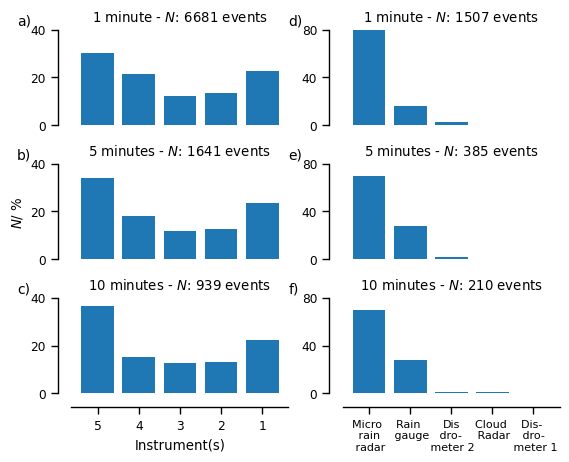

In [48]:
sns.set_context("paper")
fig = plt.figure(figsize=(16/2.54,12/2.54))
ax1 = fig.add_subplot(3, 2, 1)
ax1.bar([0,1,2,3,4],[percentages_1min[0],percentages_1min[1],percentages_1min[2],percentages_1min[3],percentages_1min[4]],
                color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue'])
sns.despine(offset=10,ax=ax1)
ax1.set_yticks([0,20,40])
ax1.set_xticks([0,1,2,3,4])
ax1.set_xticks([])
ax1.spines['bottom'].set_visible(False)
ax1.set_title('1 minute - $N$: '+str(int(total_events[0])) + ' events')
plt.text(-0.25, 1.05, 'a)', transform=ax1.transAxes, fontsize=10)

ax3 = fig.add_subplot(3, 2, 3)
ax3.bar([0,1,2,3,4],[percentages_5min[0],percentages_5min[1],percentages_5min[2],percentages_5min[3],percentages_5min[4]],
                color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue'])
sns.despine(offset=10,ax=ax3)
ax3.set_yticks([0,20,40])
ax3.set_xticks([0,1,2,3,4])
ax3.set_ylabel('$N$/ %')
ax3.set_xticks([])
ax3.spines['bottom'].set_visible(False)
ax3.set_title('5 minutes - $N$: '+str(int(total_events[1])) + ' events')
plt.text(-0.25, 1.05, 'b)', transform=ax3.transAxes, fontsize=10)

ax5 = fig.add_subplot(3, 2, 5)
ax5.bar([0,1,2,3,4],[percentages_10min[0],percentages_10min[1],percentages_10min[2],percentages_10min[3],percentages_10min[4]],
                color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue'])
sns.despine(offset=10,ax=ax5)
ax5.set_yticks([0,20,40])
ax5.set_xticks([0,1,2,3,4])
ax5.set_xlabel('Instrument(s)')
ax5.set_xticklabels(['5','4','3','2','1']);
ax5.set_title('10 minutes - $N$: '+str(int(total_events[2])) + ' events')
plt.text(-0.25, 1.05, 'c)', transform=ax5.transAxes, fontsize=10)

ax2 = fig.add_subplot(3, 2, 2)
ax2.bar([0,1,2,3,4],[percentage_1min_instrument[0],percentage_1min_instrument[1],percentage_1min_instrument[3],percentage_1min_instrument[4],percentage_1min_instrument[2]],
                color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue'])
sns.despine(offset=10,ax=ax2)
ax2.set_ylim([0,80])
ax2.set_yticks([0,40,80])
ax2.set_xticks([0,1,2,3,4])
ax2.set_xticks([])
ax2.spines['bottom'].set_visible(False)
ax2.set_title('1 minute - $N$: '+str(int(total_events_1_instrument[0])) + ' events')
plt.text(-0.25, 1.05, 'd)', transform=ax2.transAxes, fontsize=10)

ax4 = fig.add_subplot(3, 2, 4)
ax4.bar([0,1,2,3,4],[percentage_5min_instrument[0],percentage_5min_instrument[1],percentage_5min_instrument[3],percentage_5min_instrument[4],percentage_5min_instrument[2]],
                color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue'])
sns.despine(offset=10,ax=ax4)
ax4.set_ylim([0,80])
ax4.set_yticks([0,40,80])
ax4.set_xticks([0,1,2,3,4])
ax4.set_xticks([])
ax4.spines['bottom'].set_visible(False)
ax4.set_title('5 minutes - $N$: '+str(int(total_events_1_instrument[1])) + ' events')
plt.text(-0.25, 1.05, 'e)', transform=ax4.transAxes, fontsize=10)

ax6 = fig.add_subplot(3, 2, 6)
ax6.bar([0,1,2,3,4],[percentage_10min_instrument[0],percentage_10min_instrument[1],percentage_10min_instrument[3],percentage_10min_instrument[4],percentage_10min_instrument[2]],
                color=['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue'])
sns.despine(offset=10,ax=ax6)
ax6.set_ylim([0,80])
ax6.set_yticks([0,40,80])
ax6.set_xticks([0,1,2,3,4])
ax6.set_title('10 minutes - $N$: '+str(int(total_events_1_instrument[2])) + ' events')
ax6.set_xticklabels(['Micro \n rain \n radar','Rain \n gauge','Dis\n dro- \n meter 2','Cloud \n Radar','Dis- \n dro- \n meter 1'],
                    fontsize=8);
plt.text(-0.25, 1.05, 'f)', transform=ax6.transAxes, fontsize=10)
plt.subplots_adjust(wspace=0.25,hspace=0.4)

plt.savefig('../figures/detected_rain_instruments.pdf',
            format='pdf',bbox_inches='tight',orientation={'landscape'})

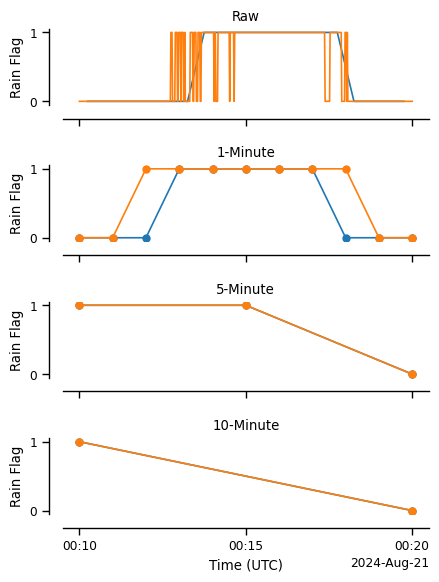

In [11]:
sns.set_context("paper")
time_slice = slice('2024-08-21 00:10:00', '2024-08-21 00:20:00')
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(4, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1)
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1)
ax1.set_title('Raw')
sns.despine(offset=10,ax=ax1)
ax1.set_xticklabels({})
ax1.set_xlabel(None)
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')


ax2 = fig.add_subplot(4, 1, 2)
cloudnet_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
mrr_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
ax2.set_title('1-Minute')
sns.despine(offset=10,ax=ax2)
ax2.set_xticklabels({})
ax2.set_xlabel(None)
ax2.set_yticks([0,1])
ax2.set_ylabel('Rain Flag')

ax3 = fig.add_subplot(4, 1, 3)
cloudnet_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
mrr_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
ax3.set_title('5-Minute')
sns.despine(offset=10,ax=ax3)
ax3.set_xticklabels({})
ax3.set_xlabel(None)
ax3.set_yticks([0,1])
ax3.set_ylabel('Rain Flag')

ax4 = fig.add_subplot(4, 1, 4)
cloudnet_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
mrr_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
ax4.set_title('10-Minute')
sns.despine(offset=10,ax=ax4)
ax4.set_xlabel('Time (UTC)')
ax4.set_yticks([0,1])
ax4.set_ylabel('Rain Flag')

plt.subplots_adjust(hspace=0.8)

plt.savefig('../figures/detected_rain_only_one_instrument_2024_08_21_00_10_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})


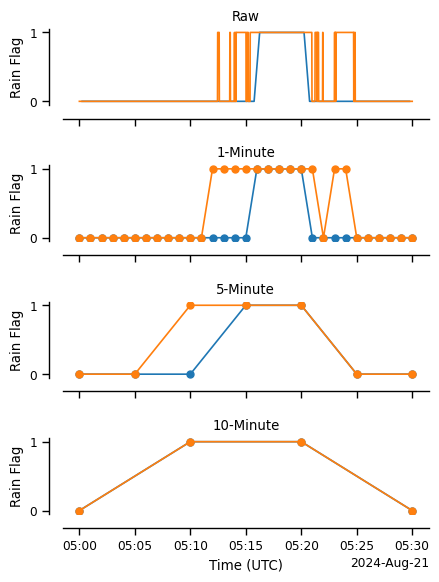

In [12]:
sns.set_context("paper")
time_slice = slice('2024-08-21 05:00:00', '2024-08-21 05:30:00')
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(4, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1)
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1)
ax1.set_title('Raw')
sns.despine(offset=10,ax=ax1)
ax1.set_xticklabels({})
ax1.set_xlabel(None)
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')

ax2 = fig.add_subplot(4, 1, 2)
cloudnet_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
mrr_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
ax2.set_title('1-Minute')
sns.despine(offset=10,ax=ax2)
ax2.set_xticklabels({})
ax2.set_xlabel(None)
ax2.set_yticks([0,1])
ax2.set_ylabel('Rain Flag')

ax3 = fig.add_subplot(4, 1, 3)
cloudnet_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
mrr_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
ax3.set_title('5-Minute')
sns.despine(offset=10,ax=ax3)
ax3.set_xticklabels({})
ax3.set_xlabel(None)
ax3.set_yticks([0,1])
ax3.set_ylabel('Rain Flag')

ax4 = fig.add_subplot(4, 1, 4)
cloudnet_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
mrr_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
ax4.set_title('10-Minute')
sns.despine(offset=10,ax=ax4)
ax4.set_xlabel('Time (UTC)')
ax4.set_yticks([0,1])
ax4.set_ylabel('Rain Flag')

plt.subplots_adjust(hspace=0.8)

plt.savefig('../figures/detected_rain_only_one_instrument_2024_08_21_05_00_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})


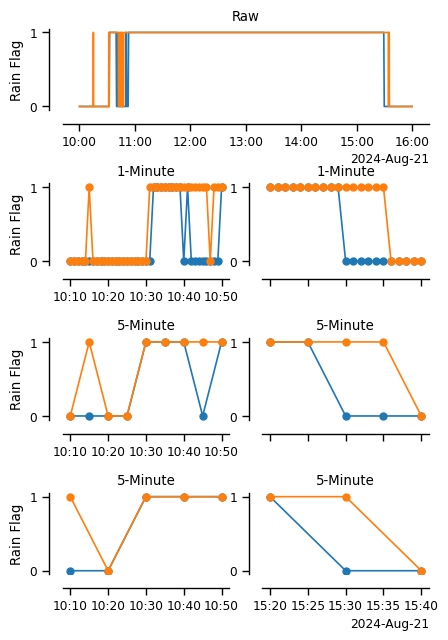

In [13]:
from matplotlib.dates import DateFormatter, MinuteLocator
import pandas as pd

sns.set_context("paper")
time_slice = slice('2024-08-21 10:00:00', '2024-08-21 16:00:00')
time_slice1 = slice('2024-08-21 10:10:00', '2024-08-21 10:50:00')
time_slice2 = slice('2024-08-21 15:20:00', '2024-08-21 15:40:00')
fig = plt.figure(figsize=(12/2.54,18/2.54))
ax1 = fig.add_subplot(4, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1)
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1)
ax1.set_title('Raw')
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(None)
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')

ax21 = fig.add_subplot(4, 2, 3)
cloudnet_flag_1min.sel(time=time_slice1).plot(
    marker='o',markersize=5, ax=ax21)
mrr_flag_1min.sel(time=time_slice1).plot(
    marker='o',markersize=5, ax=ax21)
ax21.set_title('1-Minute')
sns.despine(offset=10,ax=ax21)
ax21.set_xlabel(None)
ax21.set_yticks([0,1])
ax21.set_ylabel('Rain Flag')
ax21.set_xticklabels({})
# Create custom tick locations at multiples of 10 minutes
tick_times = pd.date_range('2024-08-21 10:10:00', '2024-08-21 10:50:00', freq='10min')
ax21.set_xticks(tick_times)
ax21.xaxis.set_major_formatter(DateFormatter('%H:%M'))


ax22 = fig.add_subplot(4, 2, 4)
cloudnet_flag_1min.sel(time=time_slice2).plot(
    marker='o',markersize=5, ax=ax22)
mrr_flag_1min.sel(time=time_slice2).plot(
    marker='o',markersize=5, ax=ax22)
ax22.set_title('1-Minute')
sns.despine(offset=10,ax=ax22)
ax22.set_xlabel(None)
ax22.set_yticks([0,1])
ax22.set_ylabel(None)
ax22.set_xticklabels({})

ax31 = fig.add_subplot(4, 2, 5)
cloudnet_flag_5min.sel(time=time_slice1).plot(
    marker='o',markersize=5, ax=ax31)
mrr_flag_5min.sel(time=time_slice1).plot(
    marker='o',markersize=5, ax=ax31)
ax31.set_title('5-Minute')
sns.despine(offset=10,ax=ax31)
ax31.set_xlabel(None)
ax31.set_yticks([0,1])
ax31.set_ylabel('Rain Flag')
# Create custom tick locations at multiples of 10 minutes
tick_times = pd.date_range('2024-08-21 10:10:00', '2024-08-21 10:50:00', freq='10min')
ax31.set_xticks(tick_times)
ax31.xaxis.set_major_formatter(DateFormatter('%H:%M'))

ax32 = fig.add_subplot(4, 2, 6)
cloudnet_flag_5min.sel(time=time_slice2).plot(
    marker='o',markersize=5, ax=ax32)
mrr_flag_5min.sel(time=time_slice2).plot(
    marker='o',markersize=5, ax=ax32)
ax32.set_title('5-Minute')
sns.despine(offset=10,ax=ax32)
ax32.set_xlabel(None)
ax32.set_yticks([0,1])
ax32.set_ylabel(None)
ax32.set_xticklabels({})

ax41 = fig.add_subplot(4, 2, 7)
cloudnet_flag_10min.sel(time=time_slice1).plot(
    marker='o',markersize=5, ax=ax41)
mrr_flag_10min.sel(time=time_slice1).plot(
    marker='o',markersize=5, ax=ax41)
ax41.set_title('5-Minute')
sns.despine(offset=10,ax=ax41)
ax41.set_xlabel(None)
ax41.set_yticks([0,1])
ax41.set_ylabel('Rain Flag')
# Create custom tick locations at multiples of 10 minutes
tick_times = pd.date_range('2024-08-21 10:10:00', '2024-08-21 10:50:00', freq='10min')
ax41.set_xticks(tick_times)
ax41.xaxis.set_major_formatter(DateFormatter('%H:%M'))

ax42 = fig.add_subplot(4, 2, 8)
cloudnet_flag_10min.sel(time=time_slice2).plot(
    marker='o',markersize=5, ax=ax42)
mrr_flag_10min.sel(time=time_slice2).plot(
    marker='o',markersize=5, ax=ax42)
ax42.set_title('5-Minute')
sns.despine(offset=10,ax=ax42)
ax42.set_xlabel(None)
ax42.set_yticks([0,1])
ax42.set_ylabel(None)


plt.subplots_adjust(hspace=0.9)

plt.savefig('../figures/detected_rain_only_one_instrument_2024_08_21_10_00_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})

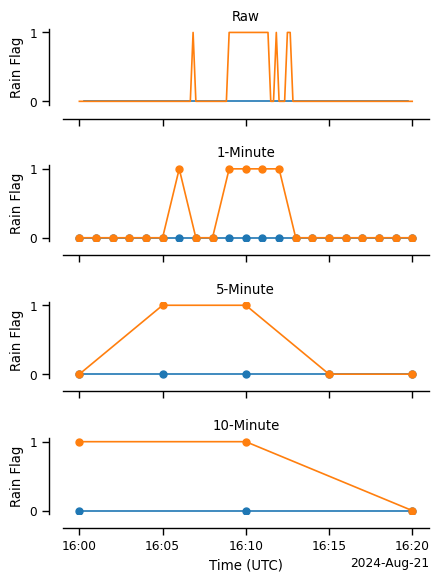

In [14]:
sns.set_context("paper")
time_slice = slice('2024-08-21 16:00:00', '2024-08-21 16:20:00')
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(4, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1)
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1)
ax1.set_title('Raw')
sns.despine(offset=10,ax=ax1)
ax1.set_xticklabels({})
ax1.set_xlabel(None)
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')

ax2 = fig.add_subplot(4, 1, 2)
cloudnet_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
mrr_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
ax2.set_title('1-Minute')
sns.despine(offset=10,ax=ax2)
ax2.set_xticklabels({})
ax2.set_xlabel(None)
ax2.set_yticks([0,1])
ax2.set_ylabel('Rain Flag')

ax3 = fig.add_subplot(4, 1, 3)
cloudnet_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
mrr_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
ax3.set_title('5-Minute')
sns.despine(offset=10,ax=ax3)
ax3.set_xticklabels({})
ax3.set_xlabel(None)
ax3.set_yticks([0,1])
ax3.set_ylabel('Rain Flag')

ax4 = fig.add_subplot(4, 1, 4)
cloudnet_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
mrr_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
ax4.set_title('10-Minute')
sns.despine(offset=10,ax=ax4)

ax4.set_xlabel('Time (UTC)')
ax4.set_yticks([0,1])
ax4.set_ylabel('Rain Flag')

plt.subplots_adjust(hspace=0.8)

plt.savefig('../figures/detected_rain_only_one_instrument_2024_08_21_16_00_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})


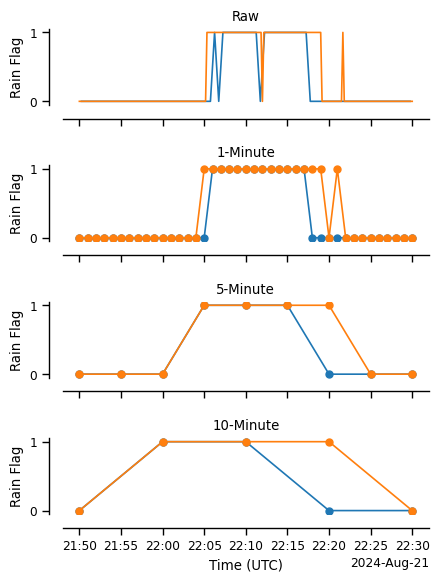

In [15]:
sns.set_context("paper")
time_slice = slice('2024-08-21 21:50:00', '2024-08-21 22:30:00')
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(4, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1)
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1)
ax1.set_title('Raw')
sns.despine(offset=10,ax=ax1)
ax1.set_xticklabels({})
ax1.set_xlabel(None)
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')

ax2 = fig.add_subplot(4, 1, 2)
cloudnet_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
mrr_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
ax2.set_title('1-Minute')
sns.despine(offset=10,ax=ax2)
ax2.set_xticklabels({})
ax2.set_xlabel(None)
ax2.set_yticks([0,1])
ax2.set_ylabel('Rain Flag')

ax3 = fig.add_subplot(4, 1, 3)
cloudnet_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
mrr_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
ax3.set_title('5-Minute')
sns.despine(offset=10,ax=ax3)
ax3.set_xticklabels({})
ax3.set_xlabel(None)
ax3.set_yticks([0,1])
ax3.set_ylabel('Rain Flag')

ax4 = fig.add_subplot(4, 1, 4)
cloudnet_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
mrr_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
ax4.set_title('10-Minute')
sns.despine(offset=10,ax=ax4)
ax4.set_xlabel('Time (UTC)')
ax4.set_yticks([0,1])
ax4.set_ylabel('Rain Flag')

plt.subplots_adjust(hspace=0.8)

plt.savefig('../figures/detected_rain_only_one_instrument_2024_08_21_21_50_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})


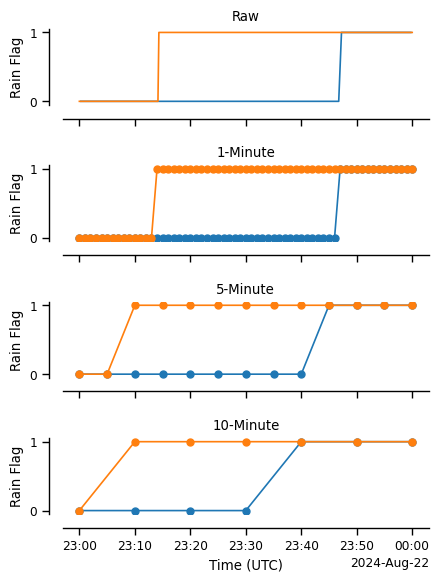

In [16]:
sns.set_context("paper")
time_slice = slice('2024-08-21 23:00:00', '2024-08-22 00:00:00')
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax1 = fig.add_subplot(4, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1)
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1)
ax1.set_title('Raw')
sns.despine(offset=10,ax=ax1)
ax1.set_xticklabels({})
ax1.set_xlabel(None)
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')

ax2 = fig.add_subplot(4, 1, 2)
cloudnet_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
mrr_flag_1min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax2)
ax2.set_title('1-Minute')
sns.despine(offset=10,ax=ax2)
ax2.set_xticklabels({})
ax2.set_xlabel(None)
ax2.set_yticks([0,1])
ax2.set_ylabel('Rain Flag')

ax3 = fig.add_subplot(4, 1, 3)
cloudnet_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
mrr_flag_5min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax3)
ax3.set_title('5-Minute')
sns.despine(offset=10,ax=ax3)
ax3.set_xticklabels({})
ax3.set_xlabel(None)
ax3.set_yticks([0,1])
ax3.set_ylabel('Rain Flag')

ax4 = fig.add_subplot(4, 1, 4)
cloudnet_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
mrr_flag_10min.sel(time=time_slice).plot(
    marker='o',markersize=5, ax=ax4)
ax4.set_title('10-Minute')
sns.despine(offset=10,ax=ax4)
ax4.set_xlabel('Time (UTC)')
ax4.set_yticks([0,1])
ax4.set_ylabel('Rain Flag')

plt.subplots_adjust(hspace=0.8)

plt.savefig('../figures/detected_rain_only_one_instrument_2024_08_21_23_00_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})

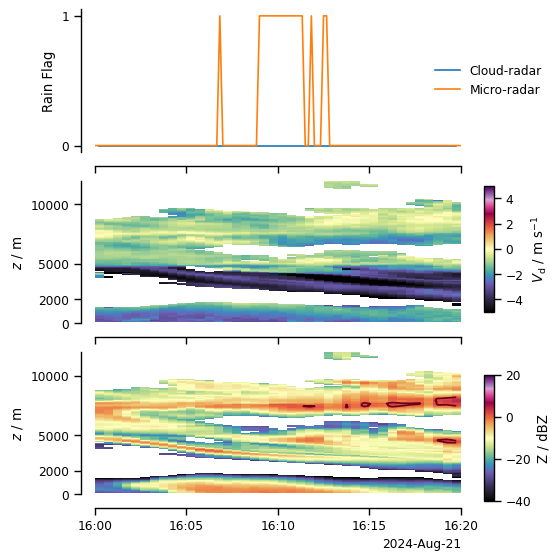

In [52]:
sns.set_context("paper")
dates = pd.to_datetime(['2024-08-21 16:00:00', '2024-08-21 16:20:00'])
time_slice = slice('2024-08-21 16:00:00', '2024-08-21 16:20:00')
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax_fig1 = fig.add_axes([0.95, 0.4, 0.02, 0.2])  # [left, bottom, width, height]
ax_fig2 = fig.add_axes([0.95, 0.1, 0.02, 0.2])  # [left, bottom, width, height]
ax1 = fig.add_subplot(3, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1,label = 'Cloud-radar')
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1,label = 'Micro-radar')
ax1.set_title(None)
ax1.legend(frameon=False,bbox_to_anchor=(0.9, 0.5), loc='center left')
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(None)
ax1.set_xticklabels({})
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')
ax1.set_xlim([dates[0],dates[1]])


ax2 = fig.add_subplot(3, 1, 2)
cs1 = (ds_cloudnet.v.sel(time=time_slice)).plot(y='height',ax=ax2,
                                                       cmap='ChaseSpectral',vmin=-5,vmax=5,
                                                       add_colorbar=False)
ax2.set_xlim([dates[0],dates[1]])
ax2.set_xticklabels({})
ax2.set_title(None)
ax2.set_ylabel(r'$z$ / m')
ax2.set_yticks([0,2000,5000,10000])
sns.despine(offset=10,ax=ax2)
plt.colorbar(cs1, cax=ax_fig1, label=r'$V_\mathrm{d}$ / m s$^{-1}$')

ax3 = fig.add_subplot(3, 1, 3)
cs2 = (ds_cloudnet.Z.sel(time=time_slice)).plot(y='height', vmin=-40,vmax=20,
                                          cmap='ChaseSpectral',ax=ax3,add_colorbar=False)
cs3 = (ds_cloudnet.Z.sel(time=time_slice)).plot.contour(y='height',levels=[1],ax=ax3)
ax3.set_title(None)
ax3.set_xlim([dates[0],dates[1]])
ax3.set_xlabel(None)
ax3.set_ylabel(r'$z$ / m')
ax3.set_yticks([0,2000,5000,10000])
sns.despine(offset=10,ax=ax3)
plt.colorbar(cs2, cax=ax_fig2, label=r'Z / dBZ')

plt.savefig('../figures/detected_rain_only_one_instrument_dbz_vd_2024_08_21_16_00_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})

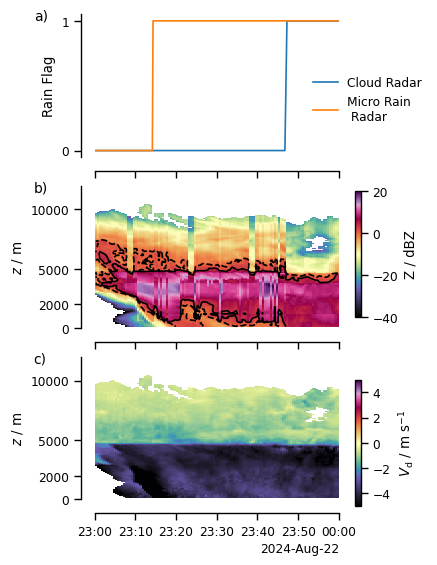

In [62]:
sns.set_context("paper")
dates = pd.to_datetime(['2024-08-21 23:00:00', '2024-08-22 00:00:00'])
time_slice = slice('2024-08-21 23:00:00', '2024-08-22 00:00:00')
fig = plt.figure(figsize=(8/2.54,16/2.54))
ax_fig1 = fig.add_axes([0.95, 0.4, 0.02, 0.2])  # [left, bottom, width, height]
ax_fig2 = fig.add_axes([0.95, 0.1, 0.02, 0.2])  # [left, bottom, width, height]
ax1 = fig.add_subplot(3, 1, 1)
ds_cloudnet.rain_detected.sel(time=time_slice).plot(ax=ax1,label = 'Cloud Radar')
ds_mrr_rainflag.sel(time=time_slice).rain_flag.plot(ax=ax1,label = 'Micro Rain \n Radar')
ax1.set_title(None)
ax1.legend(frameon=False,bbox_to_anchor=(0.85, 0.4), loc='center left')
sns.despine(offset=10,ax=ax1)
ax1.set_xlabel(None)
ax1.set_xticklabels({})
ax1.set_yticks([0,1])
ax1.set_ylabel('Rain Flag')
ax1.set_xlim([dates[0],dates[1]])
plt.text(-0.25, 0.96, 'a)', transform=ax1.transAxes, fontsize=10)

ax2 = fig.add_subplot(3, 1, 2)
cs2 = (ds_cloudnet.Z.sel(time=time_slice)).plot(y='height', vmin=-40,vmax=20,
                                          cmap='ChaseSpectral',ax=ax2,add_colorbar=False)
cs3 = (ds_cloudnet.Z.sel(time=time_slice)).plot.contour(y='height',levels=[3.1],colors='k',ax=ax2)
cs3 = (ds_cloudnet.Z.sel(time=time_slice)).plot.contour(y='height',levels=[0],linestyles='--',colors='k',ax=ax2)
ax2.set_title(None)
ax2.set_xlim([dates[0],dates[1]])
ax2.set_xlabel(None)
ax2.set_ylabel(r'$z$ / m')
ax2.set_xticklabels({})
ax2.set_yticks([0,2000,5000,10000])
sns.despine(offset=10,ax=ax2)
plt.colorbar(cs2, cax=ax_fig1, label=r'Z / dBZ')
plt.text(-0.25, 0.96, 'b)', transform=ax2.transAxes, fontsize=10)

ax3 = fig.add_subplot(3, 1, 3)
cs1 = (ds_cloudnet.v.sel(time=time_slice)).plot(y='height',ax=ax3,
                                                       cmap='ChaseSpectral',vmin=-5,vmax=5,
                                                       add_colorbar=False)

ax3.set_xlim([dates[0],dates[1]])
ax3.set_title(None)
ax3.set_ylabel(r'$z$ / m')
ax3.set_xlabel(None)
ax3.set_yticks([0,2000,5000,10000])
sns.despine(offset=10,ax=ax3)
plt.colorbar(cs1, cax=ax_fig2, label=r'$V_\mathrm{d}$ / m s$^{-1}$')
plt.text(-0.25, 0.96, 'c)', transform=ax3.transAxes, fontsize=10)

plt.savefig('../figures/detected_rain_only_one_instrument_dbz_vd_2024_08_21_23_00_UTC.png',
            dpi=400,format='png',bbox_inches='tight',orientation={'landscape'})

In [110]:
percentages_1min

[np.float64(51.040263433617724),
 np.float64(12.962131417452477),
 np.float64(13.441101631492291),
 np.float64(22.55650351743751)]

In [111]:
percentages_5min

[np.float64(51.18829981718464),
 np.float64(12.79707495429616),
 np.float64(12.5533211456429),
 np.float64(23.461304082876293)]

In [112]:
percentages_10min

[np.float64(51.43769968051119),
 np.float64(13.205537806176784),
 np.float64(12.99254526091587),
 np.float64(22.364217252396166)]

In [117]:
percentage_1min_instrument

[np.float64(80.88918380889184),
 np.float64(16.05839416058394),
 np.float64(2.5879230258792303),
 np.float64(0.46449900464499)]

In [118]:
percentage_5min_instrument

[np.float64(69.61038961038962),
 np.float64(27.532467532467532),
 np.float64(2.3376623376623376),
 np.float64(0.5194805194805194)]

In [119]:
percentage_10min_instrument

[np.float64(70.0),
 np.float64(27.61904761904762),
 np.float64(1.4285714285714286),
 np.float64(0.9523809523809524)]

In [30]:
ds_mrr_rainflag.sel(time=time_slice).rain_flag[85]

<xarray.DataArray 'rain_flag' ()> Size: 8B
[1 values with dtype=int64]
Coordinates:
    range    float32 4B ...
    time     datetime64[ns] 8B 2024-08-21T23:14:10.011652864
Attributes:
    note:     1 in case of rain

In [36]:
ds_cloudnet.rain_detected.sel(time=time_slice)[93]

<xarray.DataArray 'rain_detected' ()> Size: 8B
[1 values with dtype=float64]
Coordinates:
    time     datetime64[ns] 8B 2024-08-21T23:46:45
Attributes:
    units:      1
    long_name:  Rain detected
    comment:    1 = rain detected, 0 = no rain detected

In [133]:
time_sel=(rain_flag_1min.where((rain_flag_1min == 1) & (rain_gauge_flag_1min==1),drop=True)*0+1).time

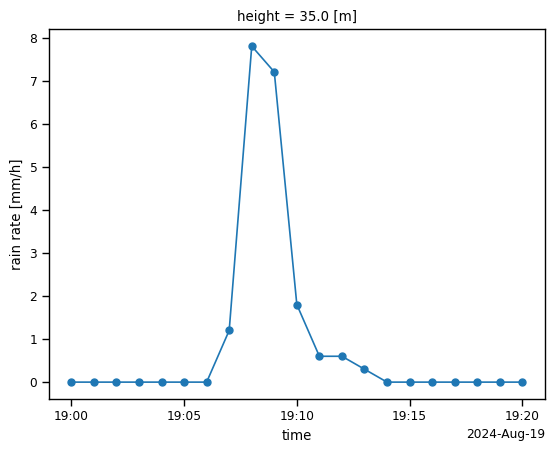

In [126]:
rain_gauge_1min.sel(time=slice('2024-08-19 19:00:00', '2024-08-19 19:20:00')).plot(marker='o',markersize=5)

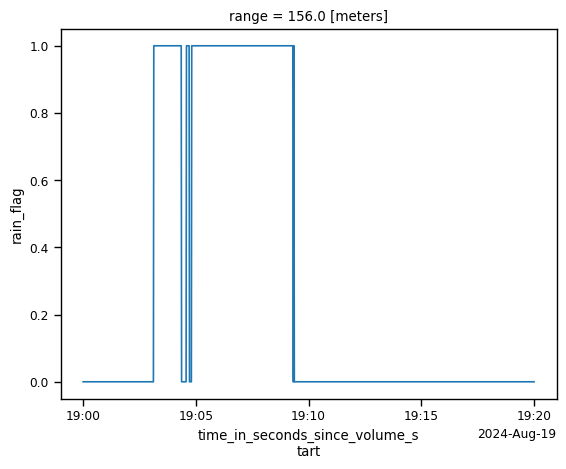

In [128]:
ds_mrr_rainflag.sel(time=slice('2024-08-19 19:00:00', '2024-08-19 19:20:00')).rain_flag.plot(label = 'Micro-radar')

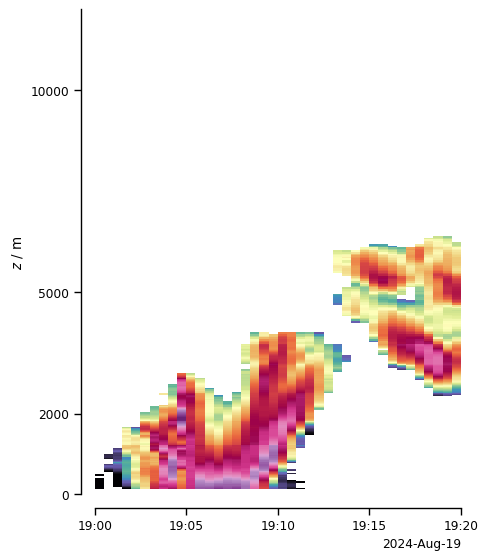

In [132]:
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax2 = fig.add_subplot(1, 1, 1)
cs2 = (ds_cloudnet.Z.sel(time=slice('2024-08-19 19:00:00', '2024-08-19 19:20:00'))).plot(y='height', vmin=-40,vmax=20,
                                          cmap='ChaseSpectral',ax=ax2,add_colorbar=False)
ax2.set_title(None)
ax2.set_xlabel(None)
ax2.set_ylabel(r'$z$ / m')
ax2.set_yticks([0,2000,5000,10000])
sns.despine(offset=10,ax=ax2)
plt.colorbar(cs2, cax=ax_fig1, label=r'Z / dBZ')

In [135]:
rain_test = rain_gauge_1min.sel(time=time_sel)

In [137]:
rain_test.where(rain_test>=6,drop=True)

<xarray.DataArray 'RR_SRM' (time: 1)> Size: 8B
array([6.])
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-09-03T23:12:00
    height   float64 8B 35.0
    range    float32 4B 156.0
Attributes:
    long_name:  rain rate
    units:      mm/h

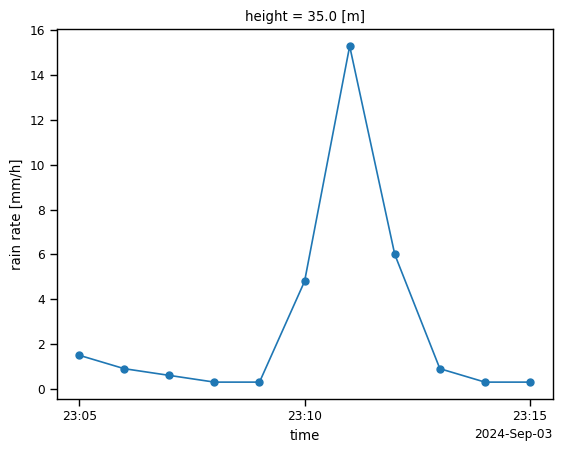

In [139]:
rain_gauge_1min.sel(time=slice('2024-09-03 23:05:00', '2024-09-03 23:15:00')).plot(marker='o',markersize=5)

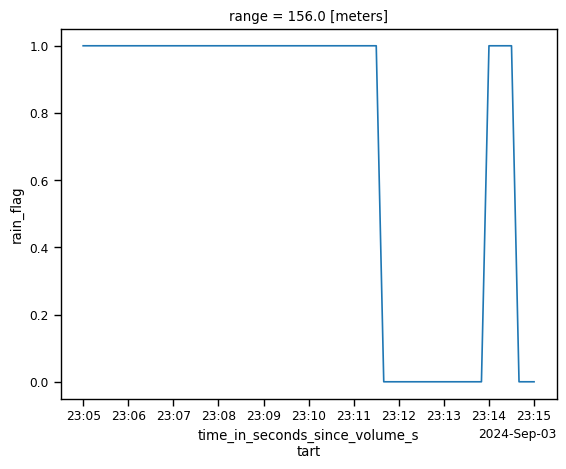

In [140]:
ds_mrr_rainflag.sel(time=slice('2024-09-03 23:05:00', '2024-09-03 23:15:00')).rain_flag.plot(label = 'Micro-radar')

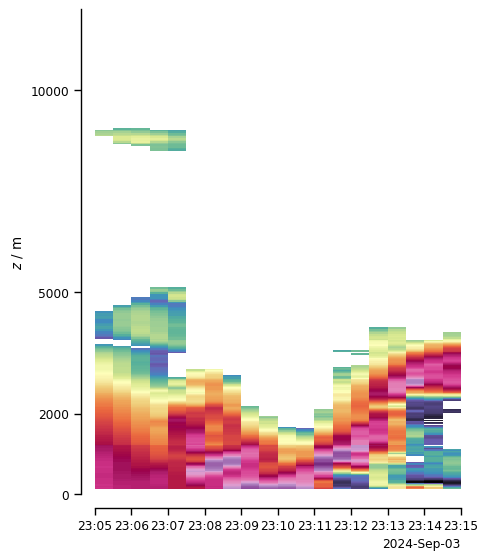

In [142]:
fig = plt.figure(figsize=(12/2.54,16/2.54))
ax2 = fig.add_subplot(1, 1, 1)
cs2 = ds_cloudnet.Z.sel(time=slice('2024-09-03 23:05:00', '2024-09-03 23:15:00')).plot(y='height', vmin=-40,vmax=20,
                                          cmap='ChaseSpectral',ax=ax2,add_colorbar=False)
ax2.set_title(None)
ax2.set_xlabel(None)
ax2.set_ylabel(r'$z$ / m')
ax2.set_yticks([0,2000,5000,10000])
sns.despine(offset=10,ax=ax2)
plt.colorbar(cs2, cax=ax_fig1, label=r'Z / dBZ')